In [1]:
# install and support packages
import pandas as pd
import numpy as np

In [2]:
# 3.2 Getting information: read in raw data with the correct encoding
df = pd.read_csv("data.csv", encoding='ISO-8859-1')
# first rows and shape of the data
print(df.head())
print(df.shape)
# info and descrition of the data
print(df.info())
print(df.describe())

# Columns that have missing data -> 541909 - 540455 = 1454 missing values in Description and 
# 541909 - 406829 = 135080 missing values in CustomerID
print("\nColumns that have missing data:")
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   

In [3]:
# 3.9 Unique Values: for Country, StockCode, and Description
# use value_counts(dropna=False) to include NaN values in the counts
print(df['Country'].nunique())
print(df['Country'].value_counts(dropna=False))
print(df['Description'].nunique())
print(df['Description'].value_counts(dropna=False))
print(df['StockCode'].nunique())
print(df['StockCode'].value_counts(dropna=False).head(20))

# Surface non-product codes specifically
non_product_codes = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE']
print("\nNon-product code counts:")
print(df['StockCode'].value_counts(dropna=False)[
    df['StockCode'].value_counts(dropna=False).index.isin(non_product_codes)
])

38
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Leban

In [4]:
# 3.8: Min/max/sum/mean/count of the Quantity and UnitPrice columns

# summarize quantity and unit price columns
print("Quantity stats:")
print(df['Quantity'].agg(['min', 'max', 'sum', 'mean', 'count']))

print("\nUnitPrice stats:")
print(df['UnitPrice'].agg(['min', 'max', 'sum', 'mean', 'count']))

# identify the negative quantities (returns) and zero/negative prices that cannot be valid sales
neg_qty_count = (df['Quantity'] < 0).sum()
print(f"\nRows with negative Quantity (returns/cancellations): {neg_qty_count}")

bad_price_count = (df['UnitPrice'] <= 0).sum()
print(f"Rows with UnitPrice <= 0 (invalid sales): {bad_price_count}")

Quantity stats:
min     -8.099500e+04
max      8.099500e+04
sum      5.176450e+06
mean     9.552250e+00
count    5.419090e+05
Name: Quantity, dtype: float64

UnitPrice stats:
min     -1.106206e+04
max      3.897000e+04
sum      2.498804e+06
mean     4.611114e+00
count    5.419090e+05
Name: UnitPrice, dtype: float64

Rows with negative Quantity (returns/cancellations): 10624
Rows with UnitPrice <= 0 (invalid sales): 2517


In [5]:
# 3.1 Creating a dataframe: Country → region lookup table from a Python dictionary (e.g. United
# Kingdom → UK&IE; France, Germany → Western Europe)

country_region_map = {
    'United Kingdom': 'UK & IE',
    'EIRE': 'UK & IE',
    'France': 'Western Europe',
    'Germany': 'Western Europe',
    'Netherlands': 'Western Europe',
    'Belgium': 'Western Europe',
    'Switzerland': 'Western Europe',
    'Austria': 'Western Europe',
    'Spain': 'Western Europe',
    'Portugal': 'Western Europe',
    'Italy': 'Western Europe',
    'Channel Islands': 'Western Europe',
    'Finland': 'Nordics',
    'Norway': 'Nordics',
    'Sweden': 'Nordics',
    'Denmark': 'Nordics',
    'Poland': 'Eastern Europe',
    'Czech Republic': 'Eastern Europe',
    'Lithuania': 'Eastern Europe',
    'Cyprus': 'Southern Europe',
    'Greece': 'Southern Europe',
    'Malta': 'Southern Europe',
    'Australia': 'Oceania',
    'Japan': 'Asia',
    'Singapore': 'Asia',
    'Hong Kong': 'Asia',
    'Saudi Arabia': 'Middle East',
    'United Arab Emirates': 'Middle East',
    'Israel': 'Middle East',
    'Bahrain': 'Middle East',
    'Lebanon': 'Middle East',
    'Canada': 'North America',
    'USA': 'North America',
    'Brazil': 'South America',
    'RSA': 'Africa'
}


region_lookup = pd.DataFrame(
    list(country_region_map.items()),
    columns=['Country', 'Region']
)
print(region_lookup)

                 Country           Region
0         United Kingdom          UK & IE
1                   EIRE          UK & IE
2                 France   Western Europe
3                Germany   Western Europe
4            Netherlands   Western Europe
5                Belgium   Western Europe
6            Switzerland   Western Europe
7                Austria   Western Europe
8                  Spain   Western Europe
9               Portugal   Western Europe
10                 Italy   Western Europe
11       Channel Islands   Western Europe
12               Finland          Nordics
13                Norway          Nordics
14                Sweden          Nordics
15               Denmark          Nordics
16                Poland   Eastern Europe
17        Czech Republic   Eastern Europe
18             Lithuania   Eastern Europe
19                Cyprus  Southern Europe
20                Greece  Southern Europe
21                 Malta  Southern Europe
22             Australia          

In [6]:
# 3.3 Slicing: Inspect row ranges with iloc (integer location). Create a unique line-item index and retrieve rows by label with loc.
# Inspect row ranges with iloc (positional)
print(df.iloc[0:5])
print(df.iloc[1000:1005])

# Create a unique line-item index and retrieve rows by label with loc
df_indexed = df.copy() # make a copy of the original dataframe to avoid modifying it
df_indexed['line_item_id'] = range(1, len(df_indexed) + 1) # create a new column with unique line-item IDs starting from 1
df_indexed = df_indexed.set_index('line_item_id') # set the new column as the index of the dataframe

# retrieve the row with line_item_id = 1 and then print the rows with line_item_id from 500 to 505
print(df_indexed.loc[1])
print(df_indexed.loc[500:505])

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
     InvoiceNo StockCode                          Description  Quantity  \
1000    536520     21123  SET/10 IVORY POLKADOT PARTY CANDLES         1   
1001    536520     21124   SET/10 BLUE POLKADOT PARTY CANDLES  

In [7]:
# 3.4 Conditional Selection: Isolate cancellations (InvoiceNo starts with 'C'), rows where Quantity <= 0, and rows
# where UnitPrice <= 0. Count each group.
 
cancellations = df[df['InvoiceNo'].astype(str).str.startswith('C')]
bad_quantity_rows = df[df['Quantity'] <= 0]
bad_price_rows = df[df['UnitPrice'] <= 0]

print(f"Cancellations (InvoiceNo starts with 'C'): {len(cancellations)}")
print(f"Rows with Quantity <= 0: {len(bad_quantity_rows)}")
print(f"Rows with UnitPrice <= 0: {len(bad_price_rows)}")

Cancellations (InvoiceNo starts with 'C'): 9288
Rows with Quantity <= 0: 10624
Rows with UnitPrice <= 0: 2517


In [8]:
# 3.5 Sorting Values: Sort by Quantity and by line revenue to find the largest bulk orders and the largest returns. 

df_temp = df.copy() # don't modify original data so copy it instead
df_temp['line_revenue'] = df_temp['Quantity'] * df_temp['UnitPrice'] # calculate line revenue for each row (quantity * price)

cols = ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'line_revenue']

print("Largest bulk orders (by Quantity):")
print(df_temp.sort_values('Quantity', ascending=False).head(10)[cols])

# most negative Quantity indicates returns, so sort ascending to find the largest returns. However most are returned for $0, so also need 
# to sort by most negative line revenue to find the largest returns by value.
print("\nLargest returns by units (most negative Quantity):")
print(df_temp.sort_values('Quantity', ascending=True).head(10)[cols])

print("\nLargest returns by value (most negative line revenue):")
print(df_temp.sort_values('line_revenue', ascending=True).head(10)[cols])

Largest bulk orders (by Quantity):
       InvoiceNo StockCode                          Description  Quantity  \
540421    581483     23843          PAPER CRAFT , LITTLE BIRDIE     80995   
61619     541431     23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   
502122    578841     84826       ASSTD DESIGN 3D PAPER STICKERS     12540   
74614     542504     37413                                  NaN      5568   
421632    573008     84077    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   
206121    554868     22197                 SMALL POPCORN HOLDER      4300   
220843    556231    85123A                                    ?      4000   
97432     544612     22053                EMPIRE DESIGN ROSETTE      3906   
270885    560599     18007  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186   
160546    550461     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   

        UnitPrice  line_revenue  
540421       2.08     168469.60  
61619        1.04      77183.60  
502122       0.

In [9]:
# 3.6 Replacing Values: Standardise country labels: 'EIRE' → 'Ireland', 'RSA' → 'South Africa', 'Unspecified' → missing

# create a clean copy of data for cleaning process 
df_clean = df.copy()

# replace the country labels with the correct values and replace 'Unspecified' with NaN
df_clean['Country'] = df_clean['Country'].replace({
    'EIRE': 'Ireland',
    'RSA': 'South Africa',
    'Unspecified': np.nan
})

# sanity check the replacement worked
print(df_clean['Country'].value_counts(dropna=False))

United Kingdom          495478
Germany                   9495
France                    8557
Ireland                   8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
NaN                        446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
South Africa                58
Lebanon 

In [10]:
# 3.7 Renaming Columns: Rename all columns to snake_case (InvoiceNo → invoice_no, UnitPrice → unit_price, …).

# continue using the same clean data copy from the previous step and rename the columns to snake_case
df_clean = df_clean.rename(columns={
    'InvoiceNo': 'invoice_no',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'UnitPrice': 'unit_price',
    'CustomerID': 'customer_id',
    'Country': 'country'
})

print(df_clean.columns.tolist())

['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


In [11]:
# 3.10 Handiling Missing Values: Quantify missingness, then decide and justify a policy for missing CustomerID and
# blank Description. Demonstrate isnull(), dropna(), fillna(). 

# Quantify missingness first
print("Missing values before handling:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# policy for missing customer_id:
# since customer_id is missing on ~25% of rows, which is substantial if we were to drop them, and these sales look legitimate
# since they have real products, real quantities and real prices, it is likely that they just never got a customer number attached. 
# we don't want to drop them since it would throw away a quarter of total revenue and possibly add bias. 
# So we should keep these rows and fill customer_id with a different label so they can be excluded later if needed for customer_id purposes
# but don't remove them from revenue/product totals.
df_clean['customer_id'] = df_clean['customer_id'].fillna('GUEST')

# policy for missing Description. 
# A blank description is a much smaller share of rows (~1,454) and has no usable product information. 
# We should drop these rows rather than keep them or fill them with a placeholder, since a fake description could be  potentially
# worse than none and its only a small fraction of the data compared to customer_id
df_clean = df_clean.dropna(subset=['description'])

print("\nMissing values after handling:")
print(df_clean.isnull().sum())

Missing values before handling:
description      1454
customer_id    135080
country           446
dtype: int64

Missing values after handling:
invoice_no        0
stock_code        0
description       0
quantity          0
invoice_date      0
unit_price        0
customer_id       0
country         446
dtype: int64


In [12]:
# 3.11 Deleting a column: Drop a column you will not use in the final analysis and explain why. *******

# unit_price was only needed to calculate revenue (quantity * unit_price, done in 3.18).
# None of the seven business questions ask about per-unit price directly - they all
# reference total revenue, units sold, or order/customer totals - so once revenue exists,
# unit_price is redundant for downstream analysis. We drop it to keep the final
# analysis-ready dataframe lean.

In [ ]:
# 3.12 Deleting a row: Remove cancellations, non-product lines, and impossible prices/quantities to build a
# clean sales DataFrame.  ****************

before = len(df_clean)

# remove cancellations, and bad quantities/prices
is_cancellation = df_clean['invoice_no'].astype(str).str.startswith('C')
is_bad_qty = df_clean['quantity'] <= 0
is_bad_price = df_clean['unit_price'] <= 0

# remove non-product codes
non_product_codes = ['POST', 'DOT', 'M', 'BANK CHARGES', 'AMAZONFEE']
is_non_product = df_clean['stock_code'].isin(non_product_codes)

df_clean = df_clean[~is_cancellation & ~is_bad_qty & ~is_bad_price & ~is_non_product]

after = len(df_clean)
print(f"Rows before: {before} | Rows after: {after} | Removed: {before - after}")

Rows before: 540455 | Rows after: 527937 | Removed: 12518


In [ ]:
# 3.13 Dropping Duplicates: Detect exact duplicates with duplicated().sum() and remove them with
# drop_duplicates(). Report how many rows were dropped 

before = len(df_clean)

duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

df_clean = df_clean.drop_duplicates()

after = len(df_clean)
print(f"Rows before: {before} | Rows after: {after} | Removed: {before - after}")

Exact duplicate rows: 5221
Rows before: 527937 | Rows after: 522716 | Removed: 5221


In [ ]:
# 3.18 Applying a function: Add a revenue = quantity * unit_price column. Use apply to clean Description (strip
# + title-case) and to flag cancelled invoices. *********

df_clean['revenue'] = df_clean['quantity'] * df_clean['unit_price']

df_clean['description'] = df_clean['description'].apply(lambda x: str(x).strip().title())

df_clean['is_cancelled'] = df_clean['invoice_no'].astype(str).apply(lambda x: x.startswith('C'))

# sanity check - should be all False, since cancellations were already removed in 3.12
print(df_clean['is_cancelled'].value_counts())

print(df_clean[['quantity', 'unit_price', 'revenue', 'description']].head())

False    522716
Name: is_cancelled, dtype: int64
   quantity  unit_price  revenue                          description
0         6        2.55    15.30   White Hanging Heart T-Light Holder
1         6        3.39    20.34                  White Metal Lantern
2         8        2.75    22.00       Cream Cupid Hearts Coat Hanger
3         6        3.39    20.34  Knitted Union Flag Hot Water Bottle
4         6        3.39    20.34       Red Woolly Hottie White Heart.


In [ ]:
# 3.17 Looping over a column: Show a for-loop / list comprehension over a column, then explain why apply is the
# preferred, faster approach.

import time

start = time.time()
titled_loop = [str(v).strip().title() for v in df_clean['description']]
loop_time = time.time() - start

start = time.time()
titled_apply = df_clean['description'].apply(lambda x: str(x).strip().title())
apply_time = time.time() - start

print(f"For-loop/list comprehension time: {loop_time:.4f}s")
print(f"apply time: {apply_time:.4f}s")

# Apply is preferred bc it is optimized for performance since it can use vectorized operations. What this means is that it 
# can operate on entire columns of data at once, rather than iterating through each row one at a time. This is better than a for loop
# bc it is more efficient and has low-level optimization already built into the library. It is also more concise which makes it 
# easier to read and maintain


For-loop/list comprehension time: 0.2467s
apply time: 0.2379s


In [ ]:
# 3.14 Grouping by values: Use groupby to compute revenue by Country and number of orders per customer 

revenue_by_country = df_clean.groupby('country')['revenue'].sum().sort_values(ascending=False)
print("Revenue by country:")
print(revenue_by_country.head(10))

orders_per_customer = df_clean.groupby('customer_id')['invoice_no'].nunique().sort_values(ascending=False)
print("\nOrders per customer:")
print(orders_per_customer.head(10))
# it will also return how many are GUEST which is a placeholder for missing customer_id

Revenue by country:
country
United Kingdom    8737732.143
Netherlands        283889.340
Ireland            276090.860
Germany            205381.150
France             184679.000
Australia          138103.810
Spain               55706.560
Switzerland         53065.600
Japan               37416.370
Belgium             36927.340
Name: revenue, dtype: float64

Orders per customer:
customer_id
GUEST      1374
12748.0     206
14911.0     199
17841.0     124
13089.0      97
15311.0      91
14606.0      90
12971.0      86
14646.0      72
16029.0      62
Name: invoice_no, dtype: int64


In [ ]:
# 3.16 Aggregating: Use agg to produce several statistics at once (total revenue, mean order value,
# transaction count) per country and per customer.

country_agg = df_clean.groupby('country').agg(
    total_revenue=('revenue', 'sum'), #total revenue: sum of revenue for each country
    mean_order_value=('revenue', 'mean'), # mean order value: avg revenue per order for each country
    transaction_count=('invoice_no', 'count') # transaction count: number of transactions for each country
).sort_values('total_revenue', ascending=False)

print("Per-country aggregates:")
print(country_agg.head(10))

customer_agg = df_clean.groupby('customer_id').agg(
    total_revenue=('revenue', 'sum'),
    mean_order_value=('revenue', 'mean'),
    transaction_count=('invoice_no', 'count')
).sort_values('total_revenue', ascending=False)

print("\nPer-customer aggregates:")
print(customer_agg.head(10))


Per-country aggregates:
                total_revenue  mean_order_value  transaction_count
country                                                           
United Kingdom    8737732.143         18.243935             478939
Netherlands        283889.340        122.260698               2322
Ireland            276090.860         35.063609               7874
Germany            205381.150         23.762715               8643
France             184679.000         22.836528               8087
Australia          138103.810        117.037127               1180
Spain               55706.560         23.047811               2417
Switzerland         53065.600         27.537935               1927
Japan               37416.370        116.561900                321
Belgium             36927.340         19.083897               1935

Per-customer aggregates:
             total_revenue  mean_order_value  transaction_count
customer_id                                                    
GUEST           15

In [30]:
# 3.19 Applying to groups: Use groupby(...).apply(...) for a custom per-customer summary (e.g. total spend and
# number of active months). **************

# invoice_date needs to be datetime before we can pull month info out of it
# don't need to convert to datetime later again
df_clean['invoice_date'] = pd.to_datetime(df_clean['invoice_date'])

def customer_summary(group):
    return pd.Series({
        'total_spend': group['revenue'].sum(),
        'n_active_months': group['invoice_date'].dt.to_period('M').nunique()
    })

per_customer_summary = df_clean.groupby('customer_id').apply(customer_summary)
print(per_customer_summary.sort_values('total_spend', ascending=False).head(10))

             total_spend  n_active_months
customer_id                              
GUEST         1522170.15             13.0
14646.0        279138.02             13.0
18102.0        259657.30             12.0
17450.0        194390.79             12.0
16446.0        168472.50              2.0
14911.0        140336.83             13.0
12415.0        124564.53             10.0
14156.0        117210.08             12.0
17511.0         91062.38             13.0
12346.0         77183.60              1.0


Monthly revenue:
invoice_date
2010-12-31     776317.500
2011-01-31     670639.460
2011-02-28     508081.540
2011-03-31     690591.840
2011-04-30     515899.661
2011-05-31     740472.330
2011-06-30     738233.990
2011-07-31     688802.671
2011-08-31     735770.220
2011-09-30    1029245.381
2011-10-31    1104063.970
2011-11-30    1453265.980
2011-12-31     614699.250
Freq: M, Name: revenue, dtype: float64


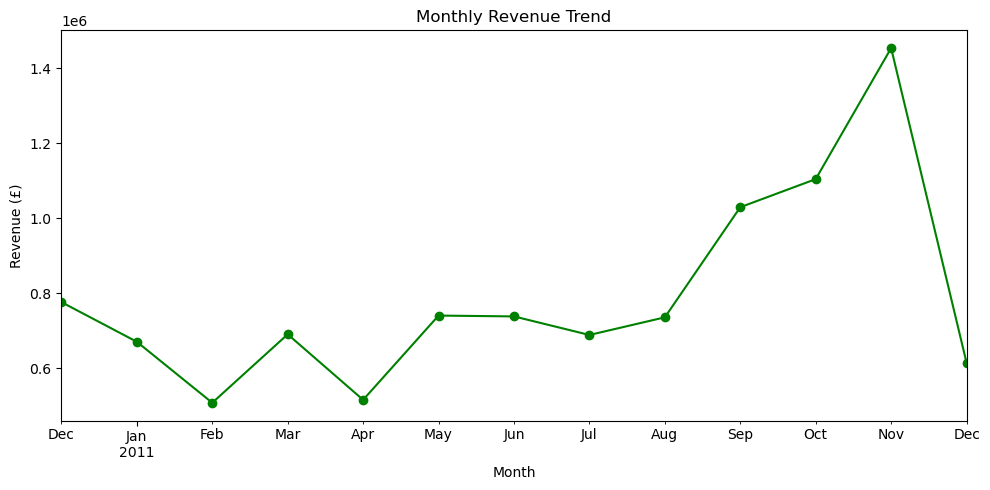

In [33]:
# 3.15 Grouping by time: Parse InvoiceDate to datetime, set it as the index, and resample monthly/weekly to
# chart the revenue trend.

# since we already set to datetime in 3.19, doesn't need to be done again
# set it as the index for resampling
df_time = df_clean.set_index('invoice_date')

# resample monthly and weekly revenue using the df_time dataframe and sum the revenue for each period
monthly_revenue = df_time['revenue'].resample('M').sum()
weekly_revenue = df_time['revenue'].resample('W').sum()

print("Monthly revenue:")
print(monthly_revenue)

import matplotlib.pyplot as plt

# plot the monthly revenue trend 
monthly_revenue.plot(kind='line', title='Monthly Revenue Trend', figsize=(10, 5), marker='o', color = 'green')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [21]:
# 3.20 Concatenating: Split your clean data into two periods (first vs second half of the year) and concat them
# back — simulating the merge of two monthly extracts. ************

In [22]:
# 3.21 Merging: Use merge to add a region column from your lookup. Compare inner vs left joins and
# note which countries fail to match. **********
